In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [7]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [11]:
df.sample(10, random_state=42)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No
1263,6818-WOBHJ,Female,1,Yes,No,68,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),89.60,6127.6,Yes
3732,3082-YVEKW,Female,0,Yes,Yes,23,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),77.15,1759.4,No
1672,4737-AQCPU,Male,0,Yes,Yes,72,Yes,Yes,DSL,Yes,...,Yes,Yes,No,No,Two year,No,Credit card (automatic),72.10,5016.65,No
811,4853-RULSV,Male,0,No,No,70,Yes,Yes,Fiber optic,Yes,...,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),104.00,7250.15,Yes
2526,5766-ZJYBB,Male,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.40,19.4,Yes


In [12]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [15]:
df.describe(include="object")

C:\Users\Dell\AppData\Local\Temp\ipykernel_18440\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [16]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [17]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_percentage[missing_percentage > 0]

Series([], dtype: float64)

In [18]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [19]:
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate customer IDs: 0


In [20]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [21]:
df["TotalCharges"].dtype

dtype('float64')

In [22]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [23]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [24]:
df.isnull().sum().sum()

np.int64(0)

In [25]:
for column in df.columns:
    print("\n", "="*50)
    print(column)
    print(df[column].unique()[:20])


customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 '9763-GRSKD', '7469-LKBCI', '8091-TTVAX', '0280-XJGEX', '5129-JLPIS',
 '3655-SNQYZ', '8191-XWSZG', '9959-WOFKT', '4190-MFLUW', '4183-MYFRB']
Length: 20, dtype: str

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

SeniorCitizen
[0 1]

Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30]

PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length:

In [26]:
df.nunique().sort_values()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

In [27]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


C:\Users\Dell\AppData\Local\Temp\ipykernel_18440\3872804544.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [28]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [29]:
churn_percentage = (
    df["Churn"].value_counts(normalize=True) * 100
)

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

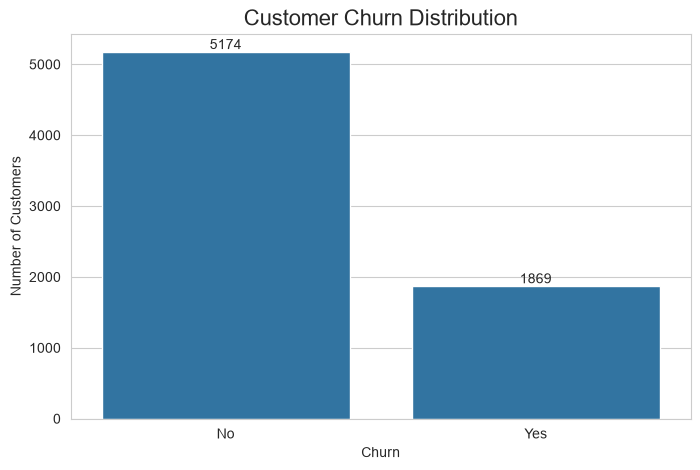

In [31]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution", fontsize=16)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

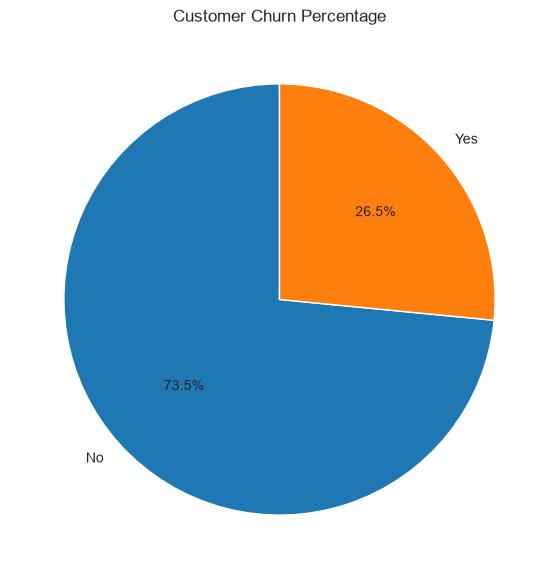

In [32]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")

plt.show()

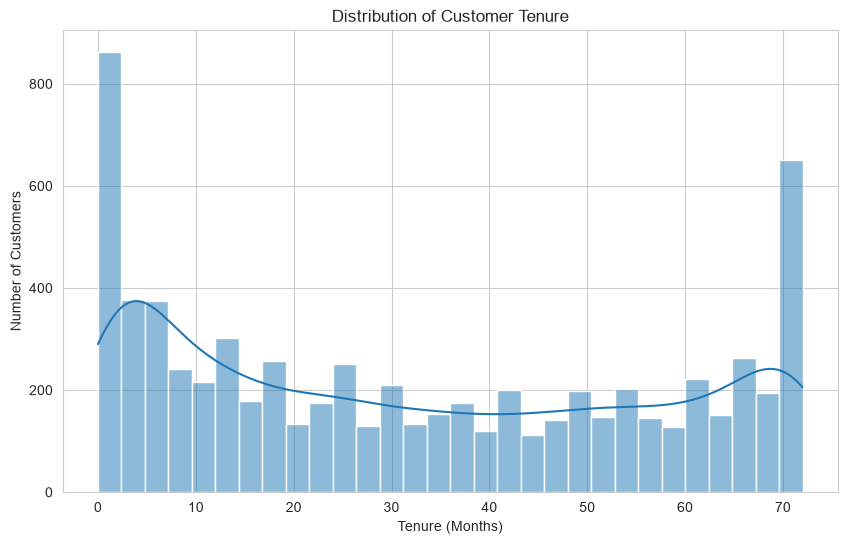

In [33]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

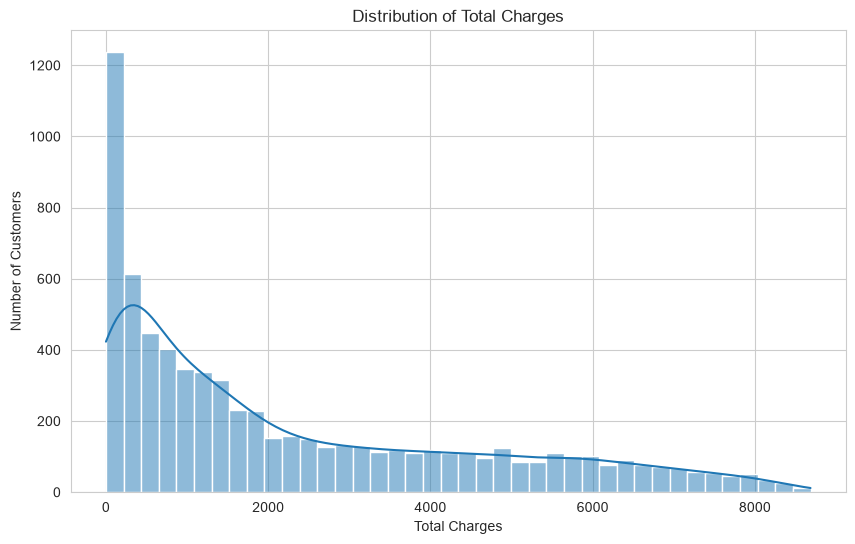

In [34]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="TotalCharges",
    bins=40,
    kde=True
)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

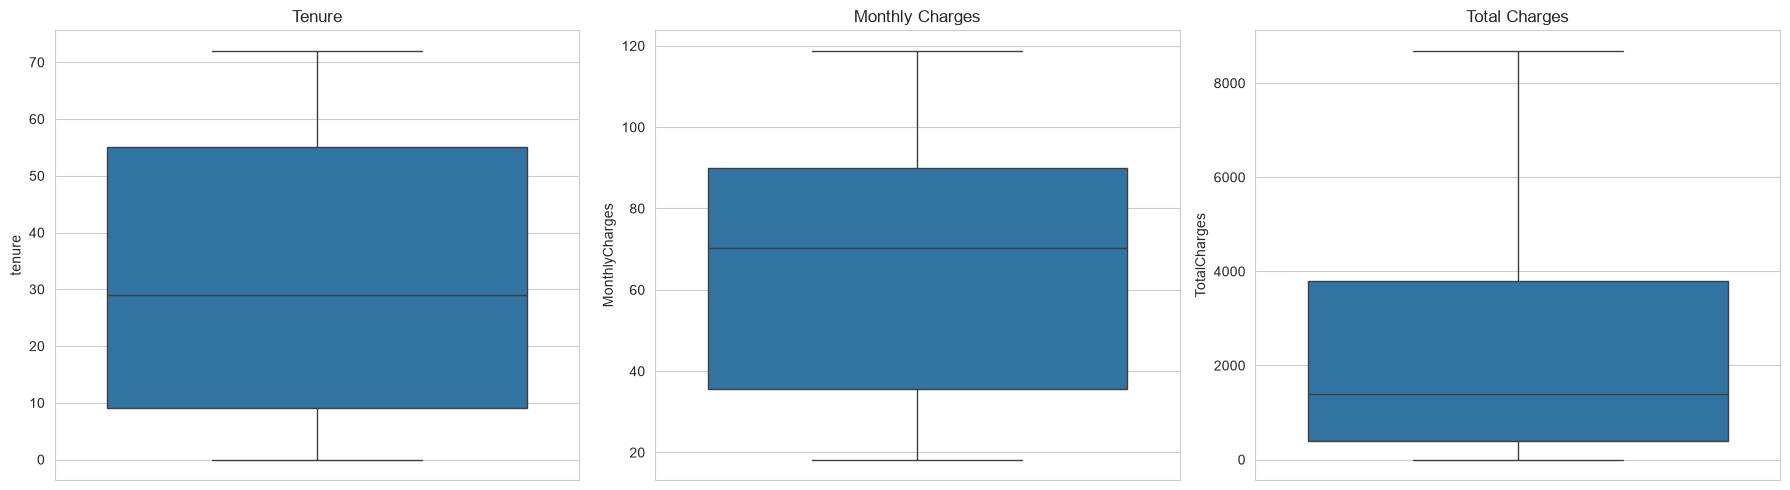

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, y="tenure", ax=axes[0])
axes[0].set_title("Tenure")

sns.boxplot(data=df, y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Monthly Charges")

sns.boxplot(data=df, y="TotalCharges", ax=axes[2])
axes[2].set_title("Total Charges")

plt.tight_layout()
plt.show()

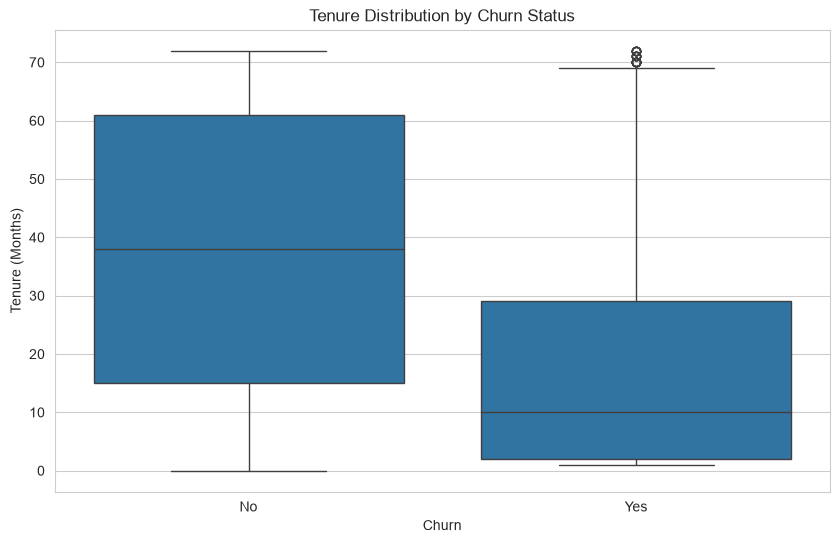

In [36]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

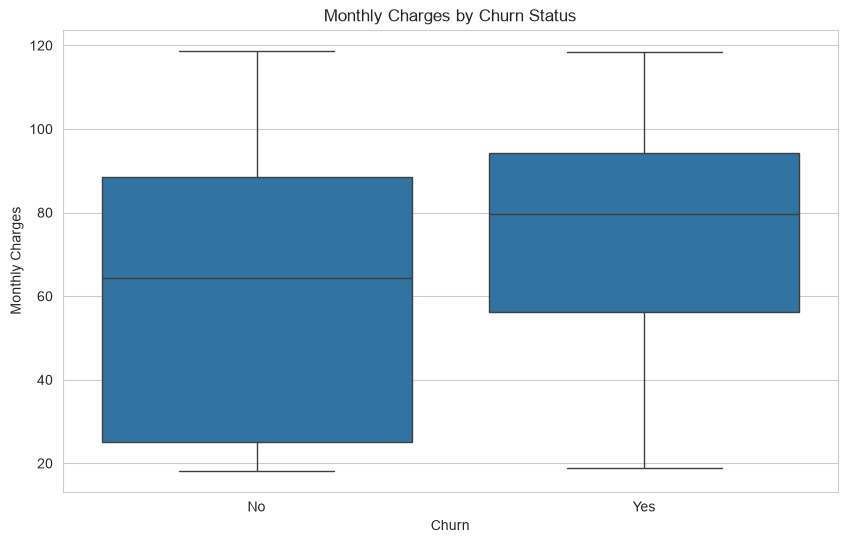

In [37]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

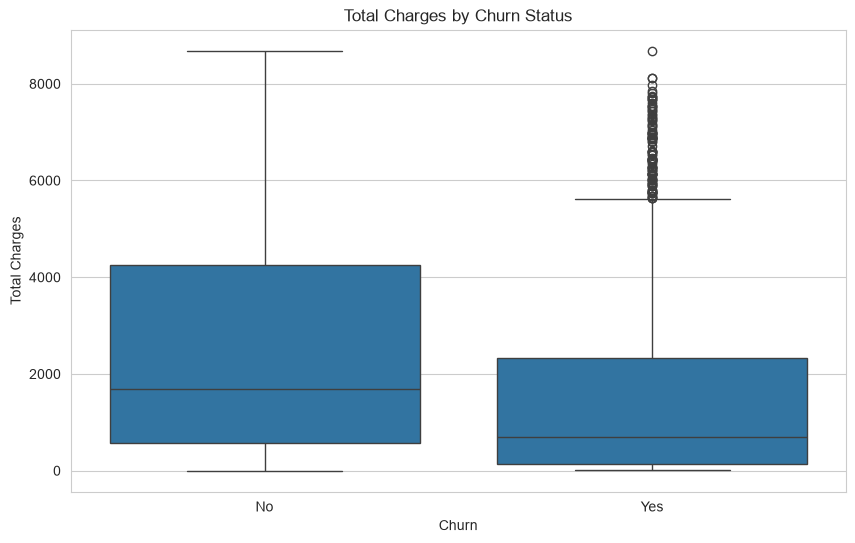

In [38]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

In [39]:
categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [40]:
for column in categorical_features:

    churn_rate = pd.crosstab(
        df[column],
        df["Churn"],
        normalize="index"
    ) * 100

    print("\n" + "="*70)
    print(column)
    print(churn_rate.round(2))


gender
Churn      No    Yes
gender              
Female  73.08  26.92
Male    73.84  26.16

Partner
Churn       No    Yes
Partner              
No       67.04  32.96
Yes      80.34  19.66

Dependents
Churn          No    Yes
Dependents              
No          68.72  31.28
Yes         84.55  15.45

PhoneService
Churn            No    Yes
PhoneService              
No            75.07  24.93
Yes           73.29  26.71

MultipleLines
Churn                No    Yes
MultipleLines                 
No                74.96  25.04
No phone service  75.07  24.93
Yes               71.39  28.61

InternetService
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40

OnlineSecurity
Churn                   No    Yes
OnlineSecurity                   
No                   58.23  41.77
No internet service  92.60   7.40
Yes                  85.39  14.61

OnlineBackup
Churn                   No    Yes
Online

In [41]:
def plot_churn_rate(column):

    churn_rate = (
        pd.crosstab(
            df[column],
            df["Churn"],
            normalize="index"
        )["Yes"] * 100
    ).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        x=churn_rate.index,
        y=churn_rate.values
    )

    plt.title(f"Churn Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Churn Rate (%)")

    plt.xticks(rotation=45)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%"
        )

    plt.tight_layout()
    plt.show()

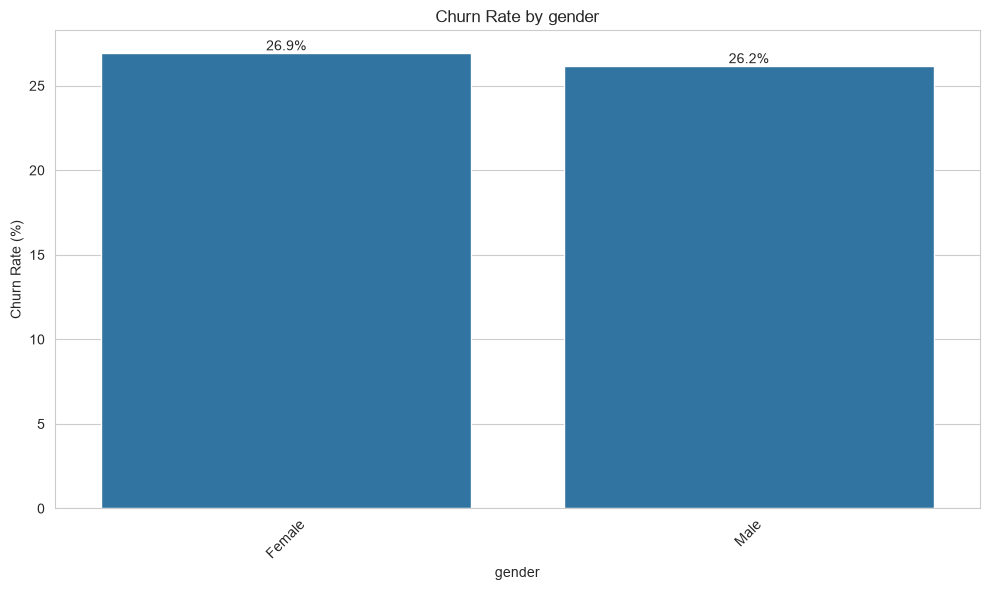

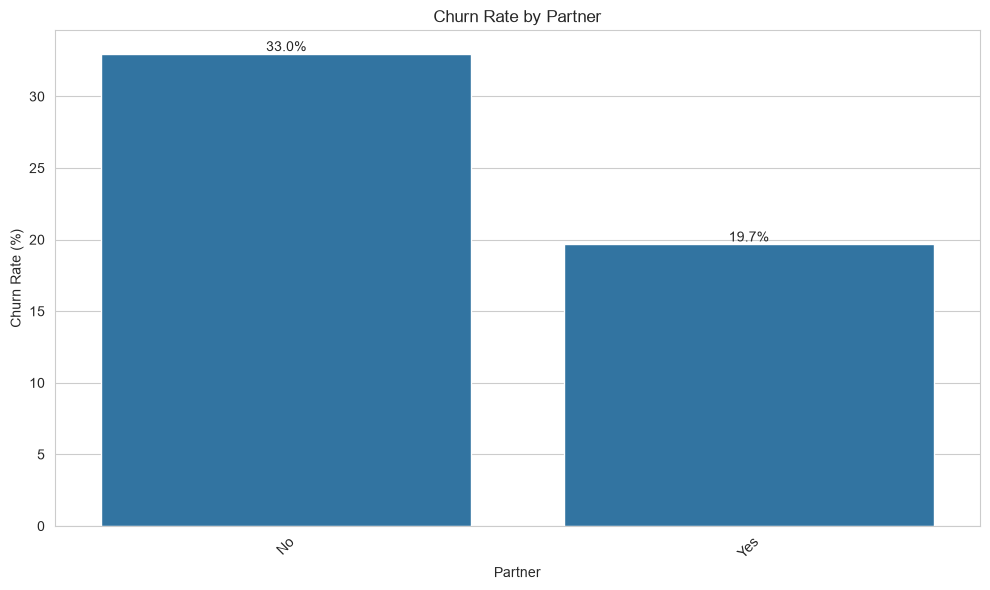

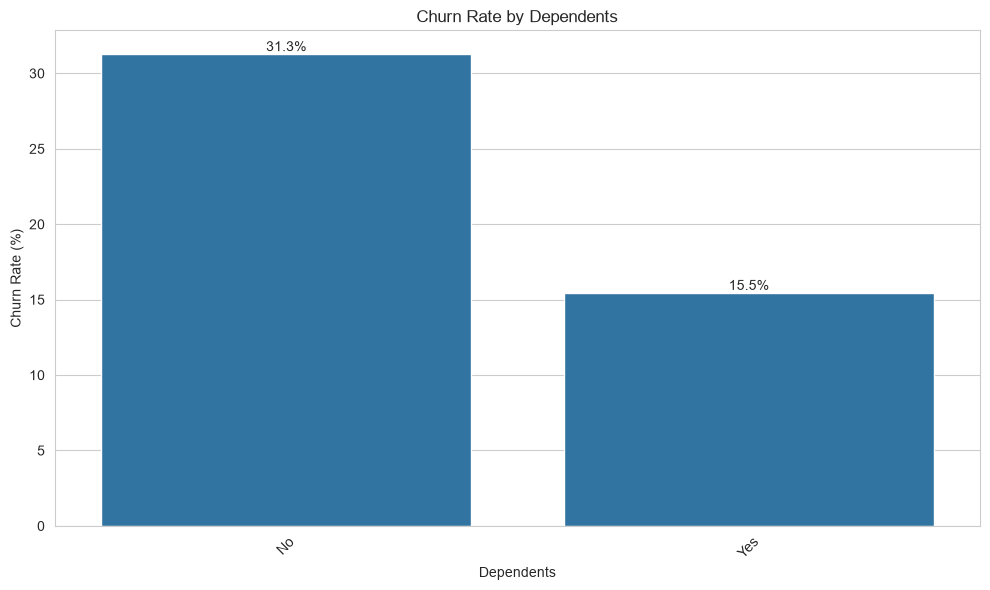

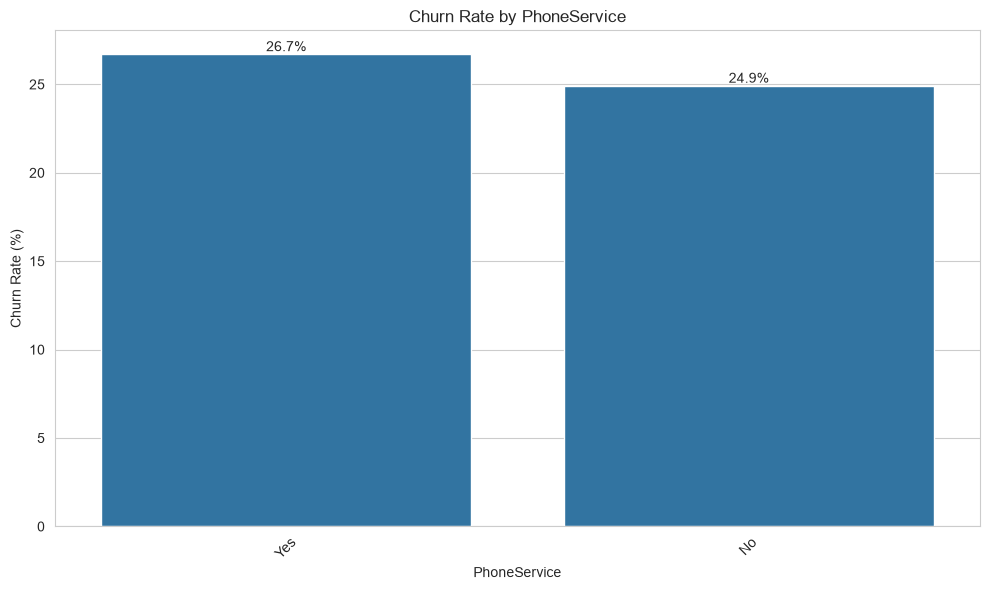

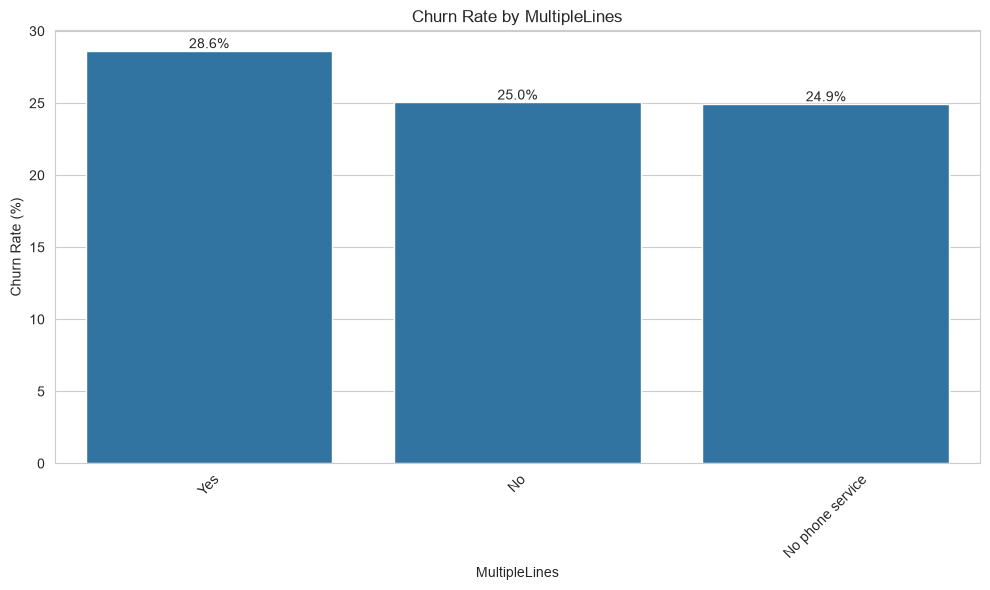

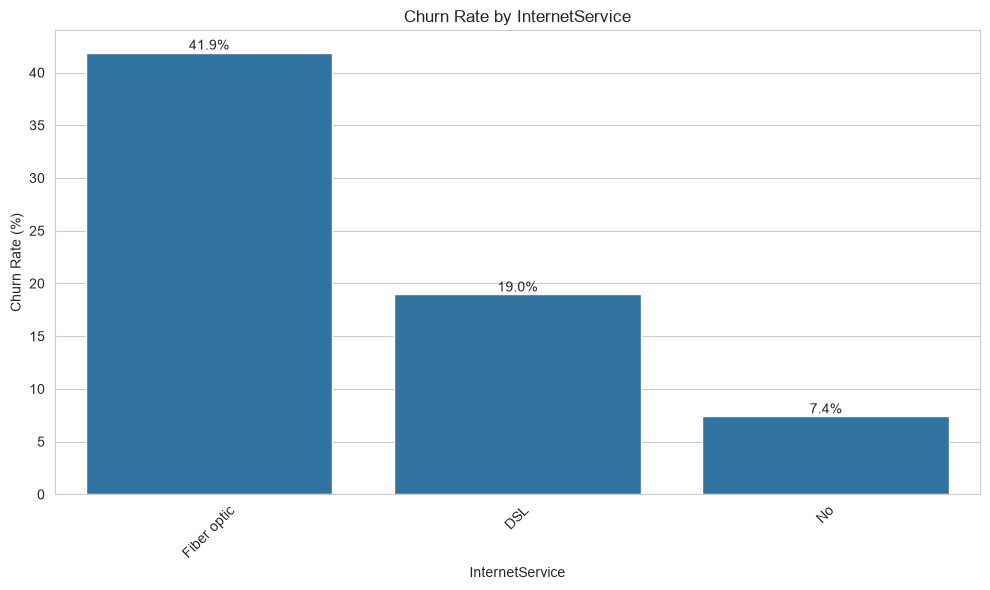

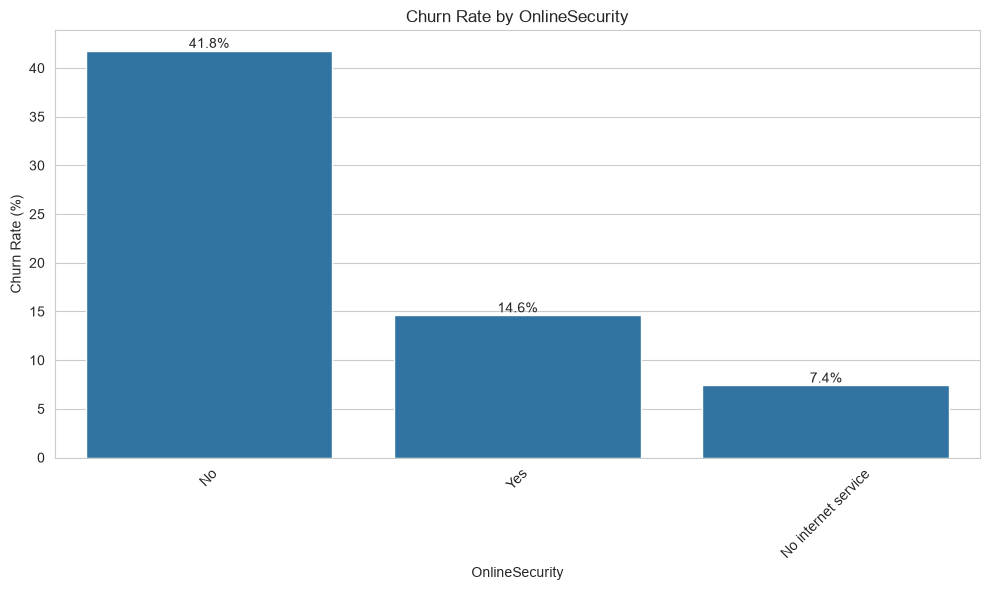

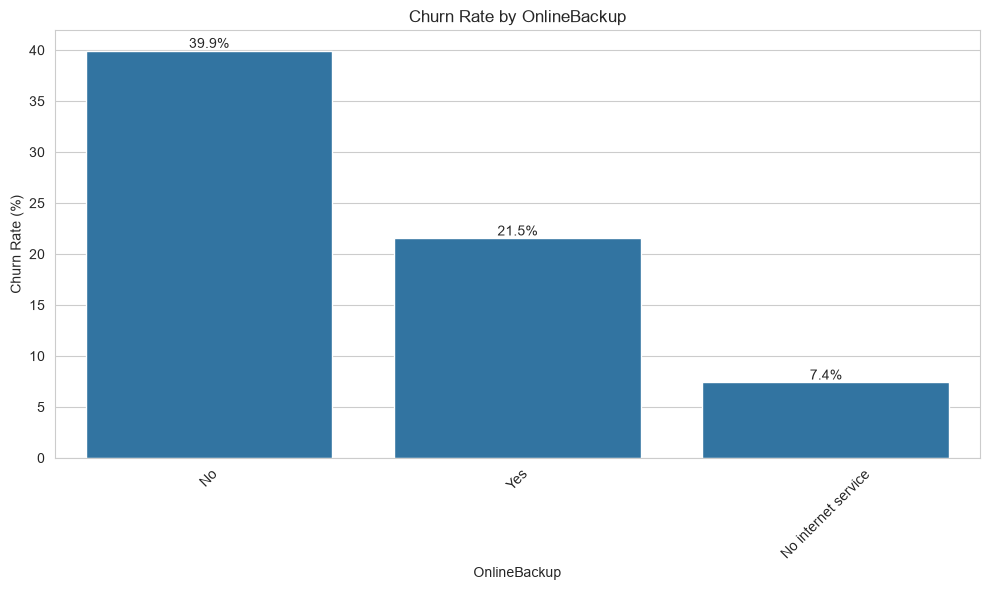

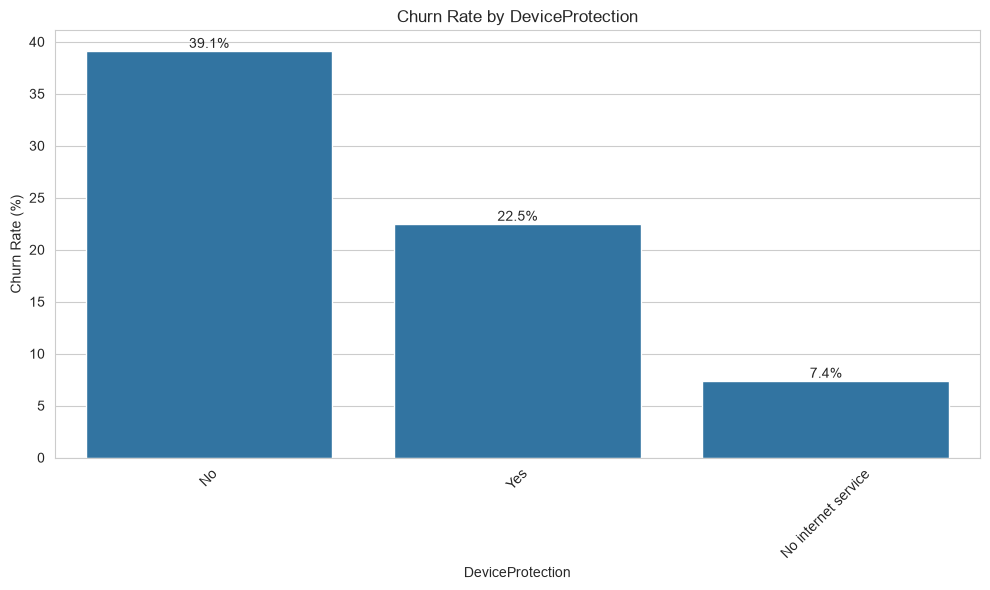

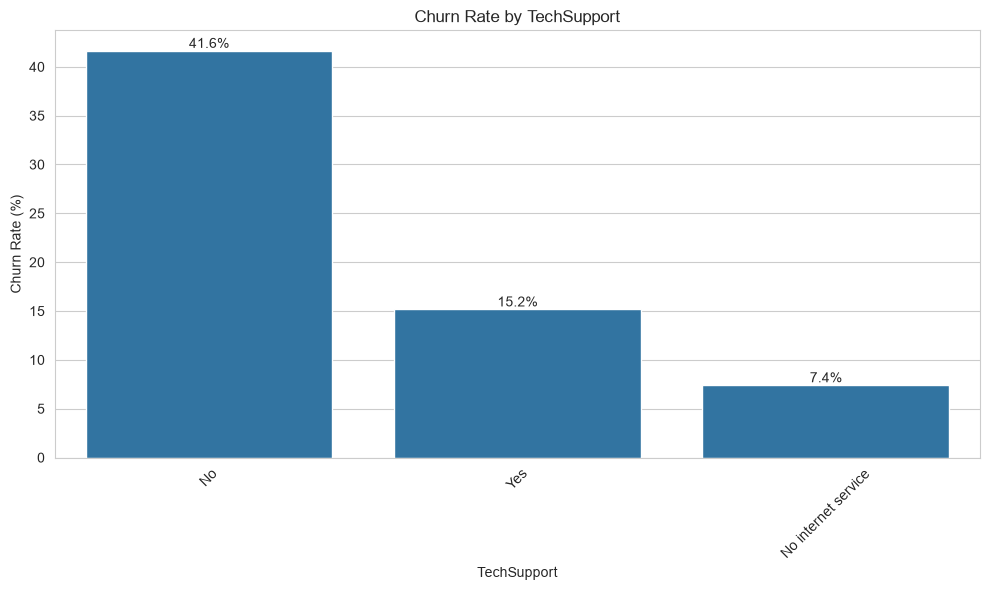

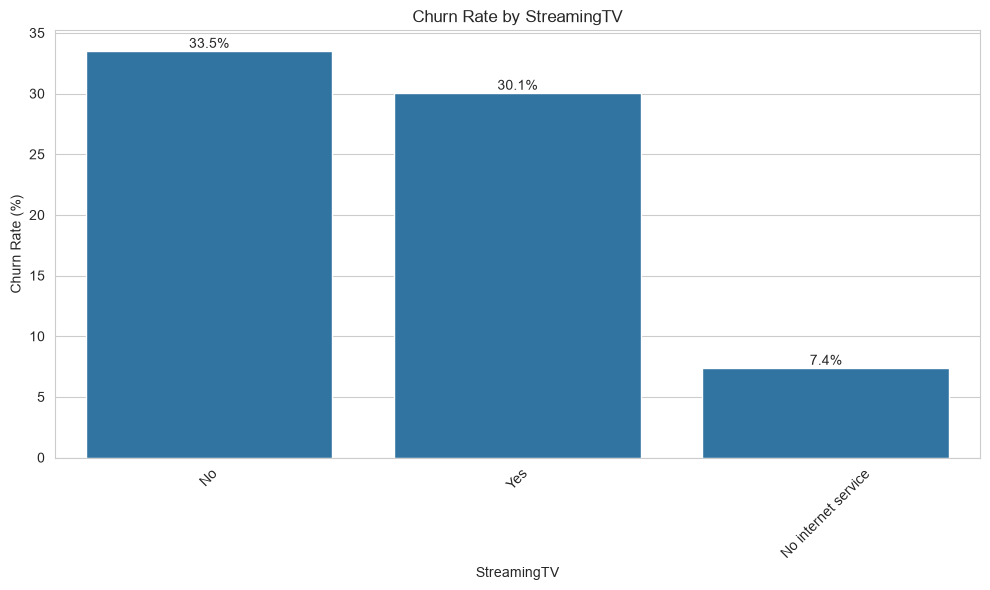

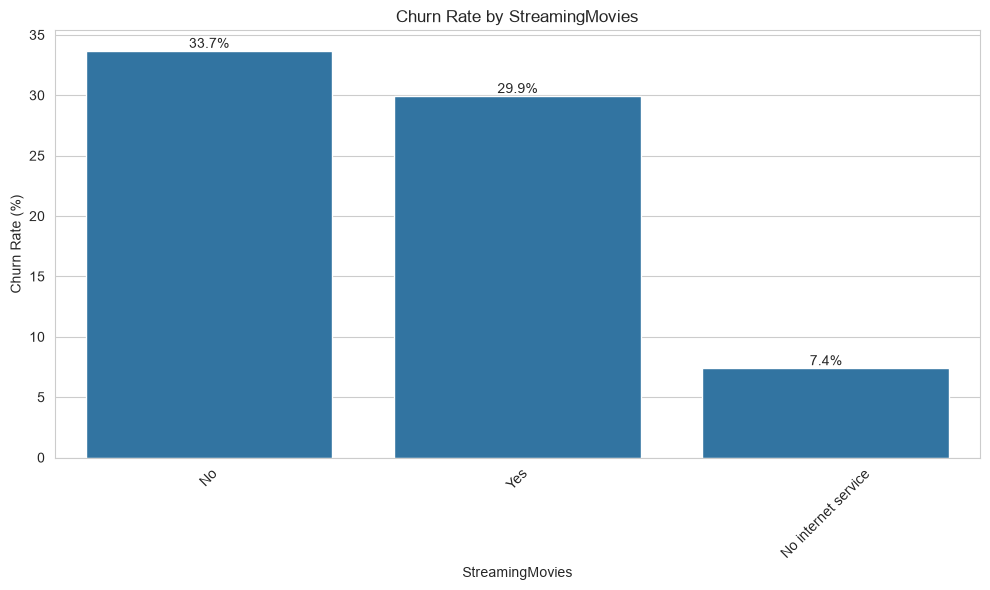

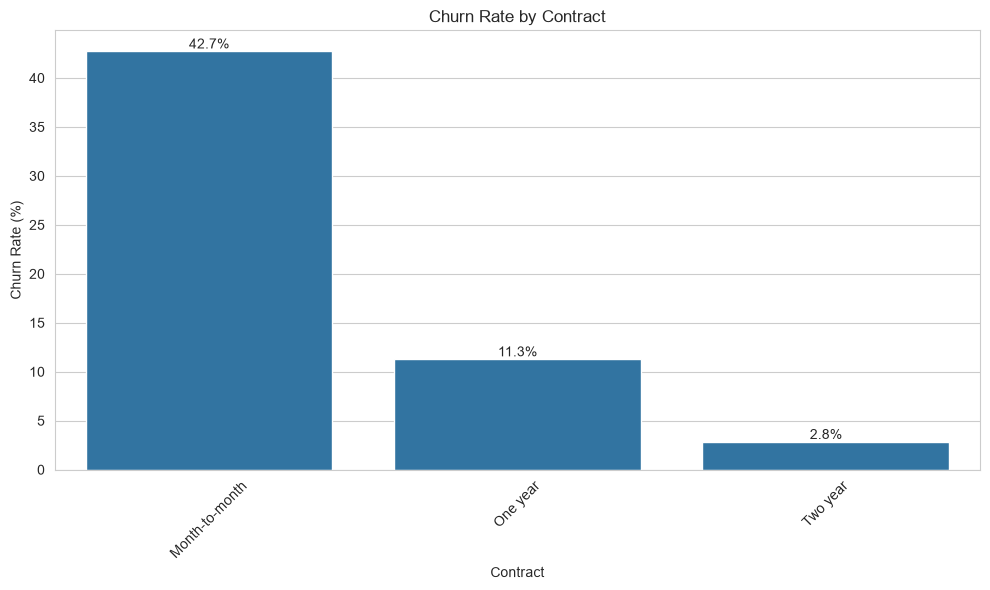

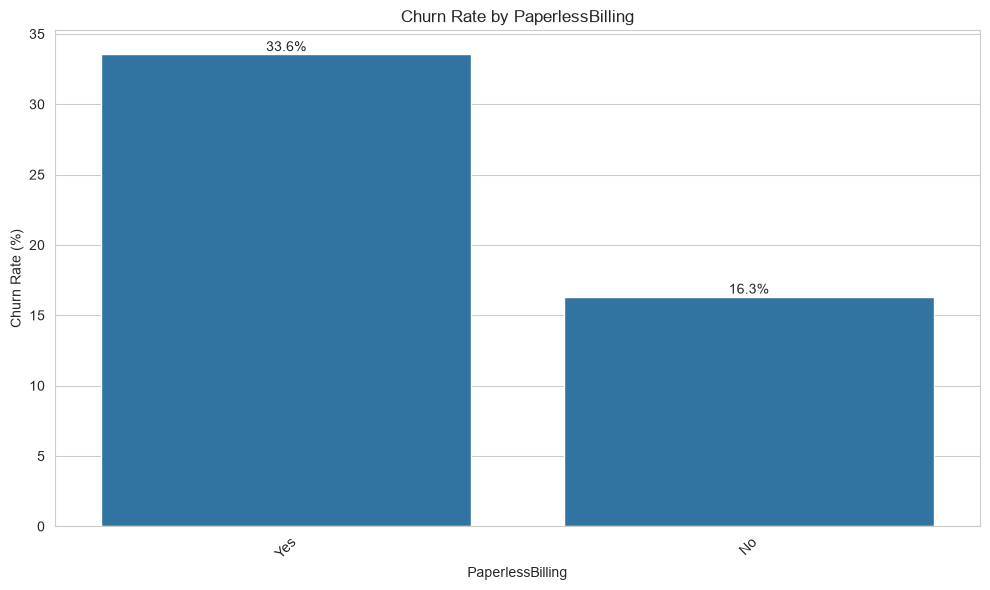

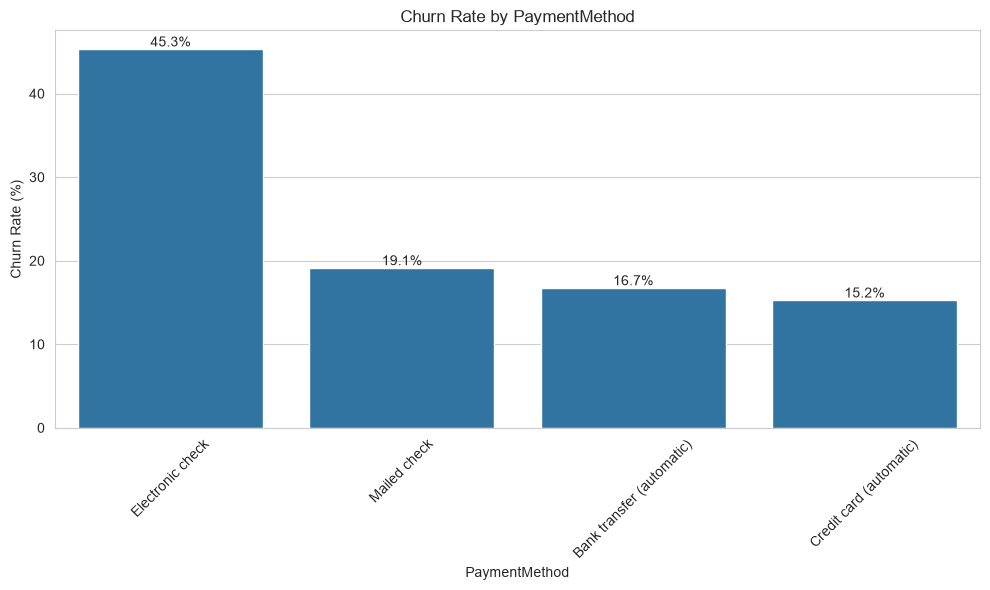

In [42]:
for column in categorical_features:
    plot_churn_rate(column)

In [43]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


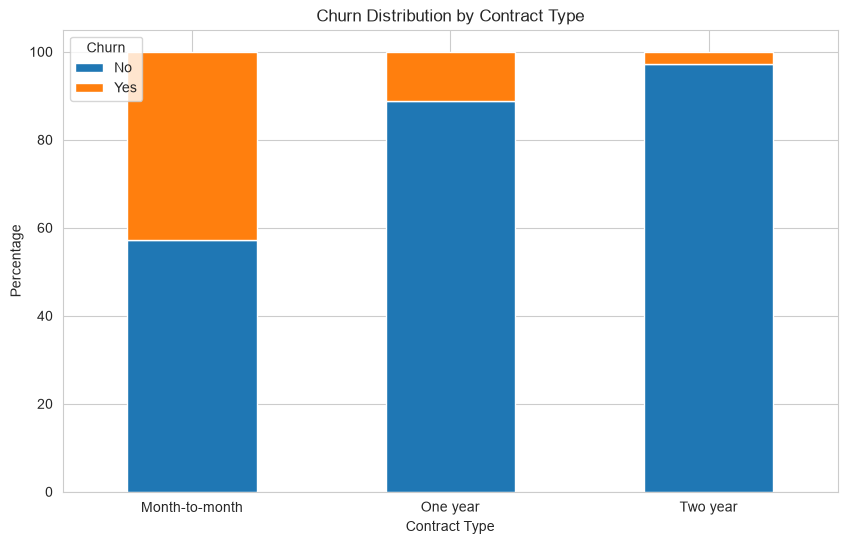

In [44]:
contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Churn Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")

plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [45]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


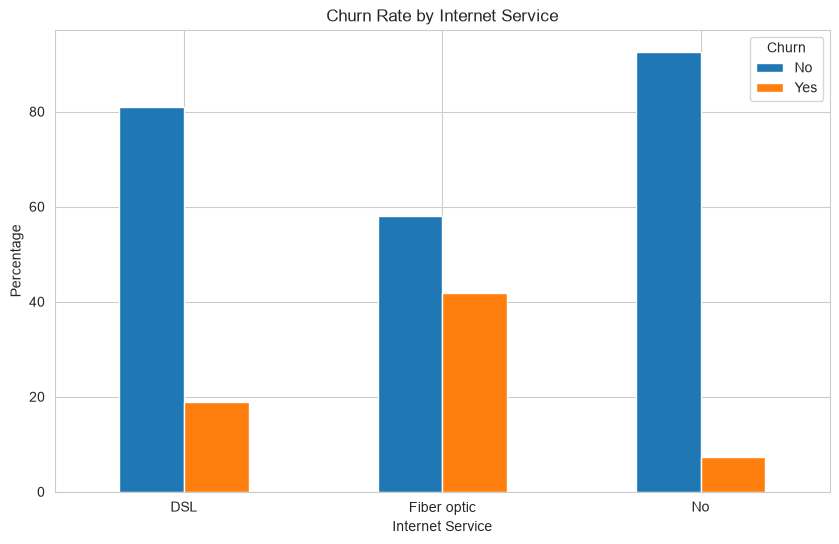

In [46]:
internet_churn.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

In [47]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


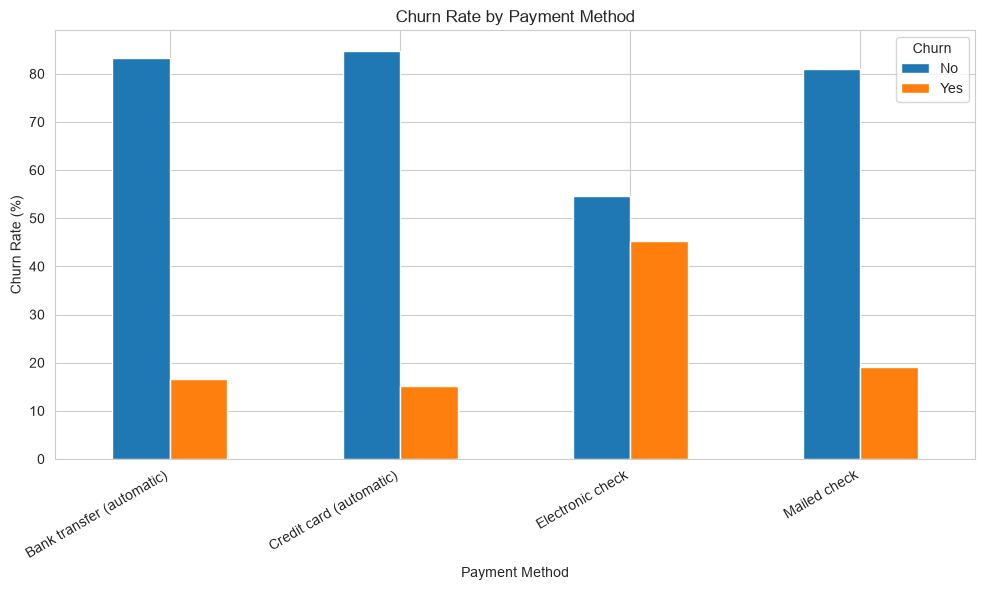

In [48]:
payment_churn.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

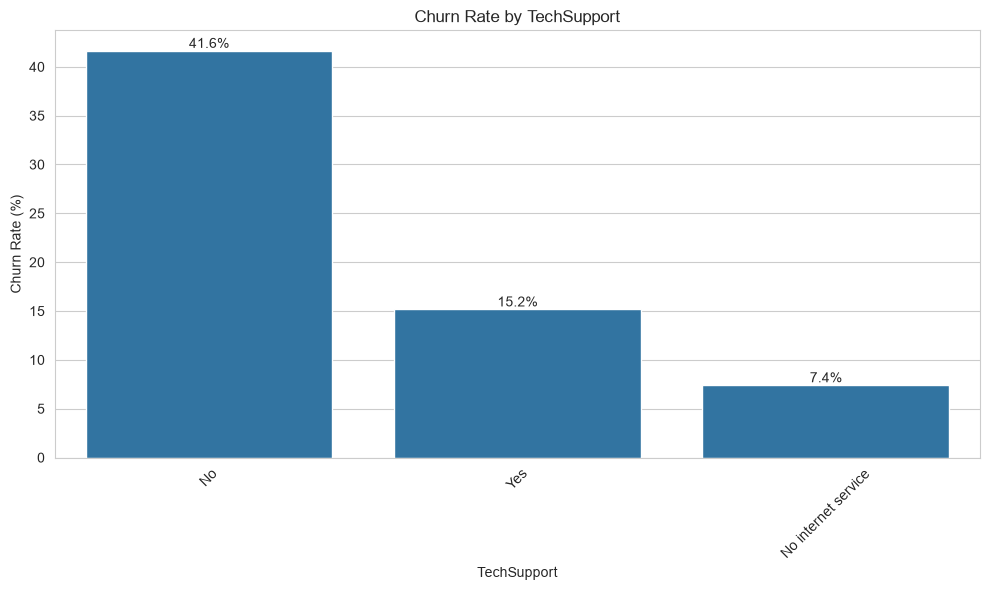

In [49]:
plot_churn_rate("TechSupport")

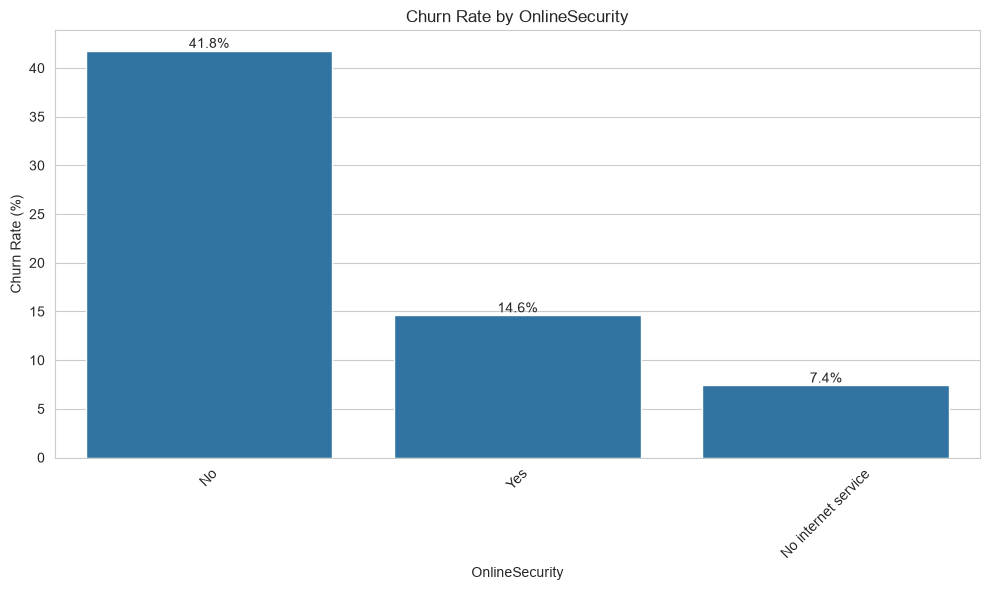

In [50]:
plot_churn_rate("OnlineSecurity")

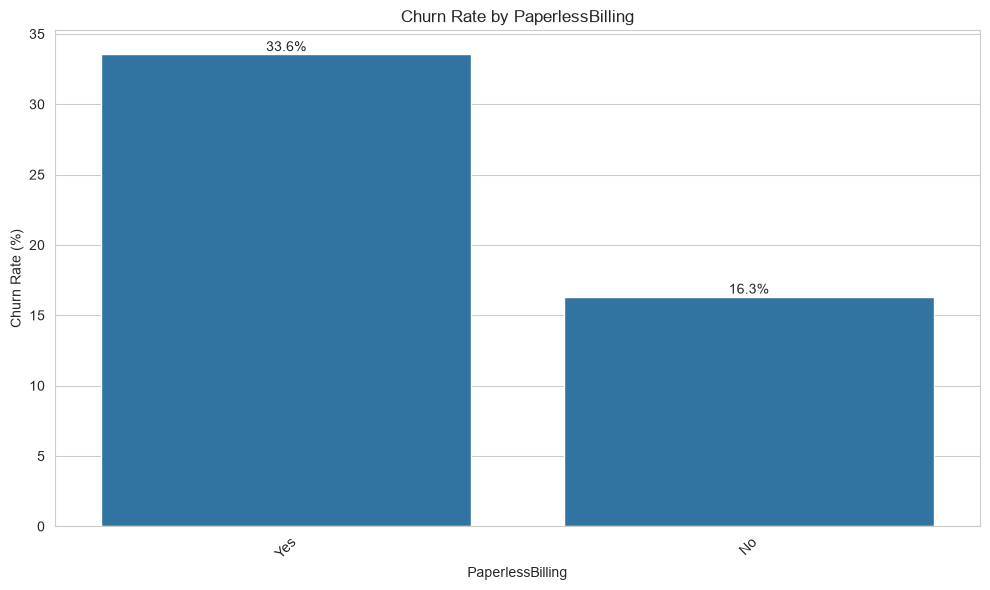

In [51]:
plot_churn_rate("PaperlessBilling")

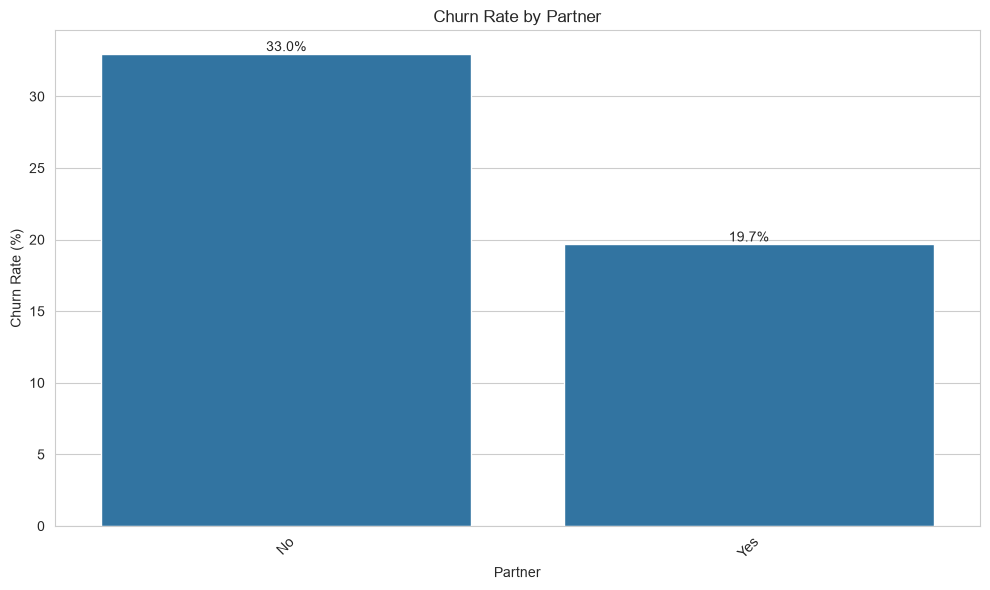

In [52]:
plot_churn_rate("Partner")

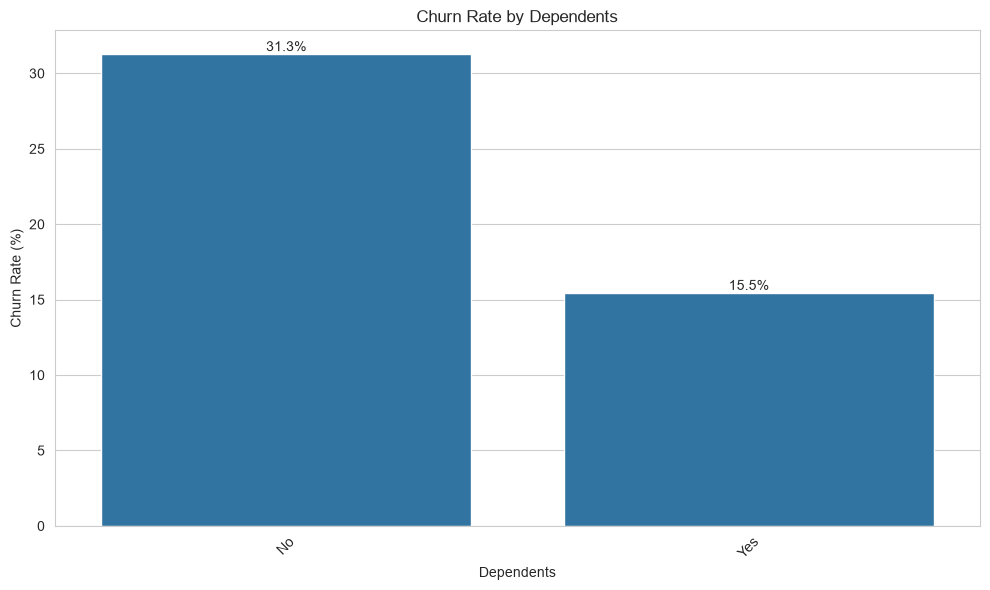

In [53]:
plot_churn_rate("Dependents")

In [54]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


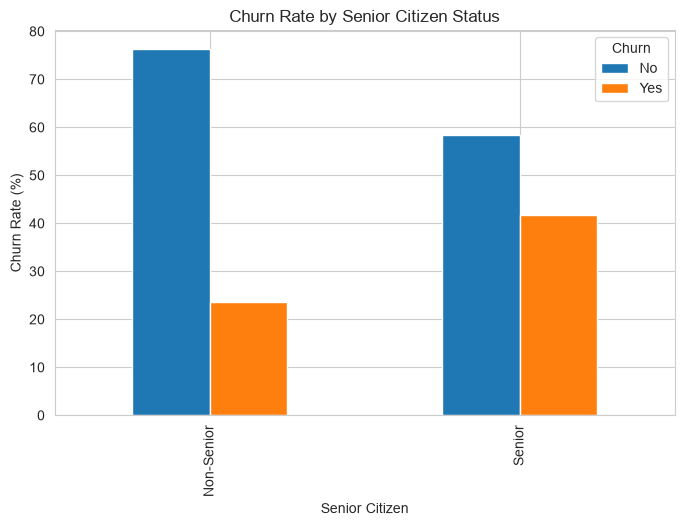

In [55]:
senior_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")

plt.xticks(
    [0, 1],
    ["Non-Senior", "Senior"]
)

plt.show()

In [56]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 Months",
        "7-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

In [57]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,No,Yes
TenureGroup,,
0-6 Months,47.062795,52.937205
7-12 Months,64.113475,35.886525
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-72 Months,90.486824,9.513176


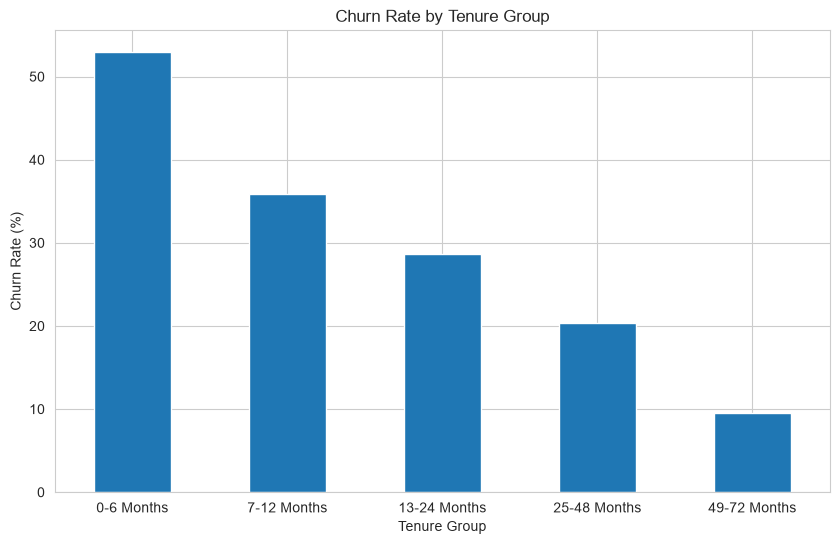

In [58]:
tenure_churn["Yes"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [59]:
df["MonthlyChargeGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 40, 60, 80, 100, 130],
    labels=[
        "0-40",
        "41-60",
        "61-80",
        "81-100",
        "101+"
    ]
)

In [60]:
charge_churn = pd.crosstab(
    df["MonthlyChargeGroup"],
    df["Churn"],
    normalize="index"
) * 100

charge_churn

Churn,No,Yes
MonthlyChargeGroup,,
0-40,88.356910,11.643090
41-60,74.444444,25.555556
61-80,67.580535,32.419465
81-100,62.981859,37.018141
101+,71.951220,28.048780


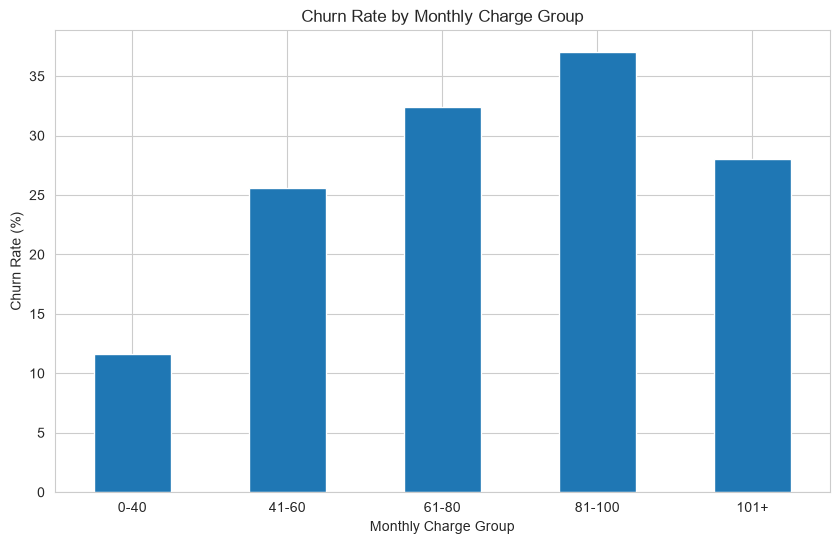

In [61]:
charge_churn["Yes"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Churn Rate by Monthly Charge Group")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [63]:
# Select numerical columns
numerical_data = df.select_dtypes(include=["int64", "float64"])

# Calculate correlation matrix
correlation = numerical_data.corr()

# Display correlation values
correlation

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


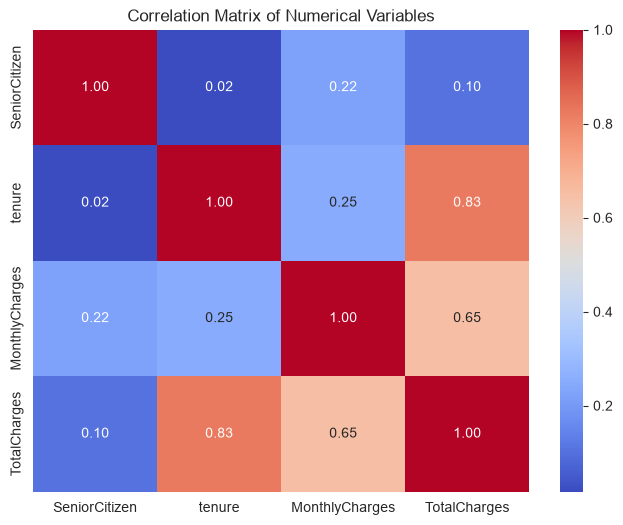

In [64]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [65]:
df["ChurnNumeric"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

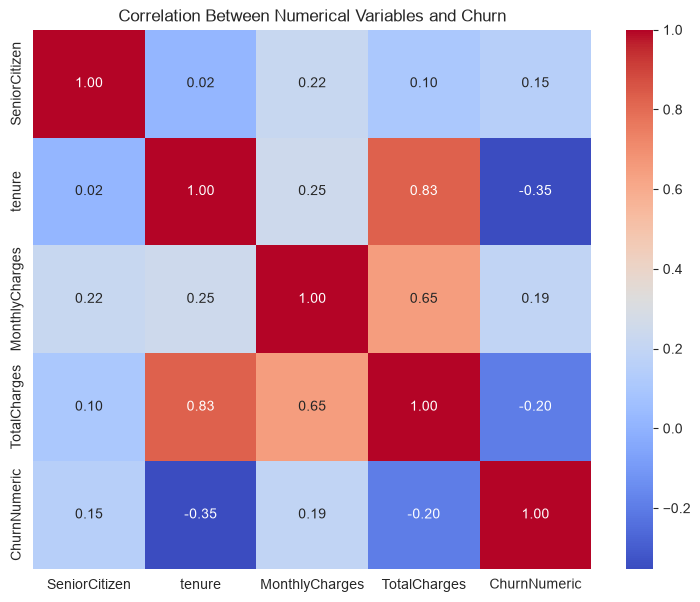

In [66]:
correlation_data = df[
    [
        "SeniorCitizen",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "ChurnNumeric"
    ]
]

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables and Churn")

plt.show()

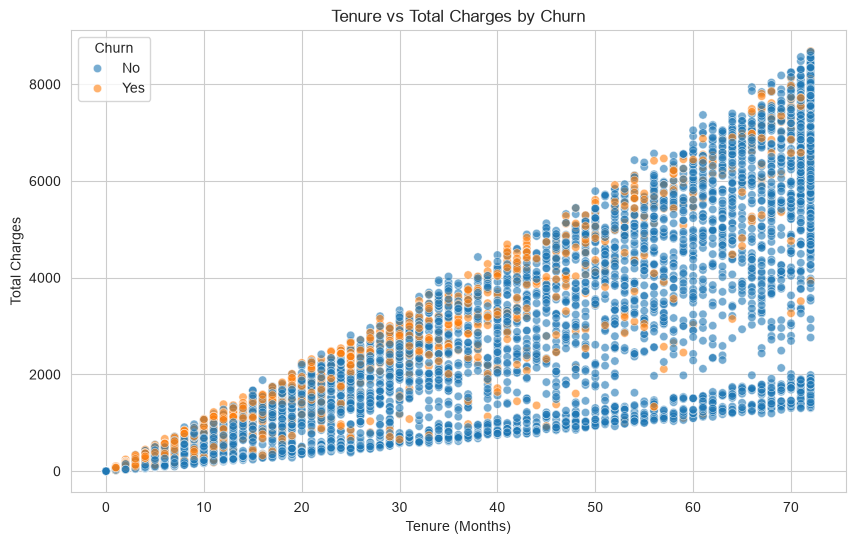

In [67]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="TotalCharges",
    hue="Churn",
    alpha=0.6
)

plt.title("Tenure vs Total Charges by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Total Charges")

plt.show()

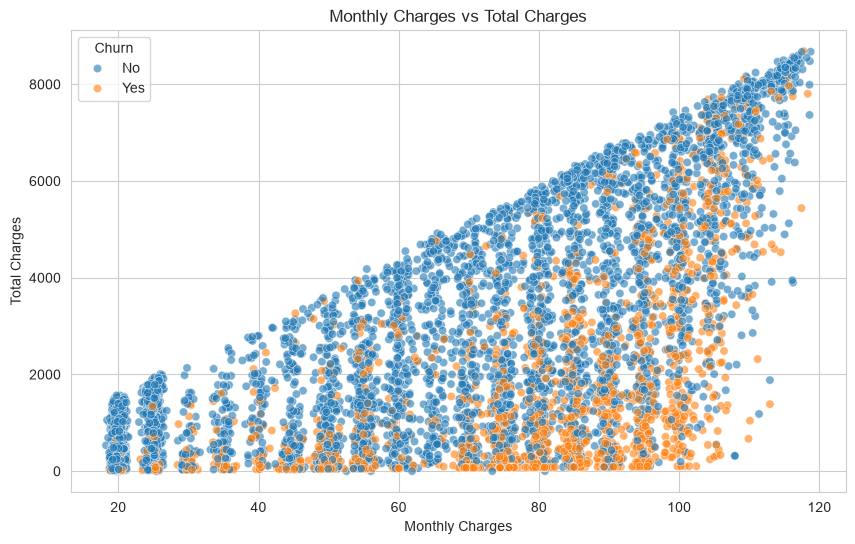

In [68]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="MonthlyCharges",
    y="TotalCharges",
    hue="Churn",
    alpha=0.6
)

plt.title("Monthly Charges vs Total Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")

plt.show()

In [76]:
pivot = pd.pivot_table(
    df,
    values="ChurnNumeric",
    index="TenureGroup",
    columns="Contract",
    aggfunc="mean"
) * 100

pivot

Contract,Month-to-month,One year,Two year
TenureGroup,,,
0-6 Months,55.201699,10.256410,0.000000
7-12 Months,41.996558,10.588235,0.000000
13-24 Months,37.720488,8.121827,0.000000
25-48 Months,32.917706,10.617761,2.189781
49-72 Months,26.023392,12.933754,3.325416


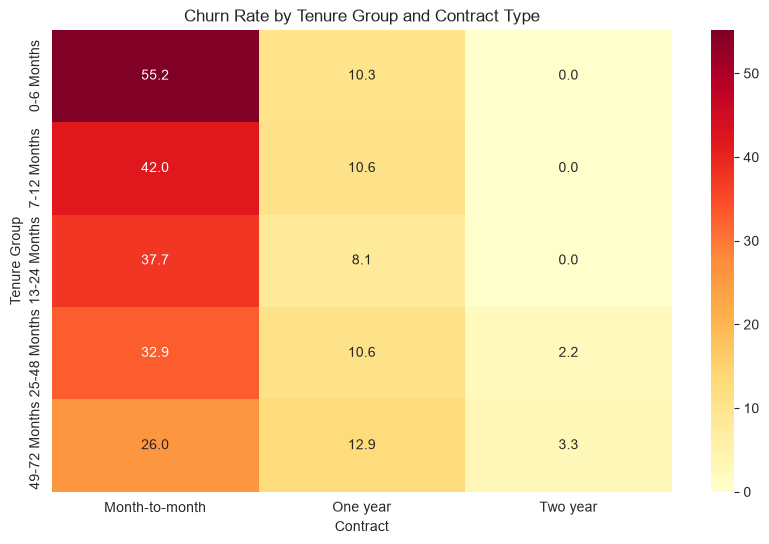

In [77]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Churn Rate by Tenure Group and Contract Type")
plt.xlabel("Contract")
plt.ylabel("Tenure Group")

plt.show()

In [78]:
pivot2 = pd.pivot_table(
    df,
    values="ChurnNumeric",
    index="InternetService",
    columns="Contract",
    aggfunc="mean"
) * 100

pivot2

Contract,Month-to-month,One year,Two year
InternetService,,,
DSL,32.215863,9.298246,1.910828
Fiber optic,54.605263,19.294991,7.226107
No,18.893130,2.472527,0.783699


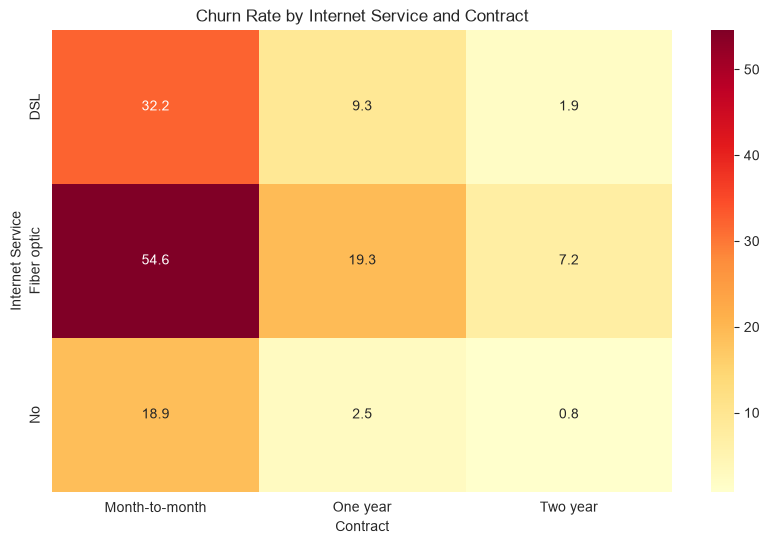

In [79]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot2,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Churn Rate by Internet Service and Contract")
plt.xlabel("Contract")
plt.ylabel("Internet Service")

plt.show()

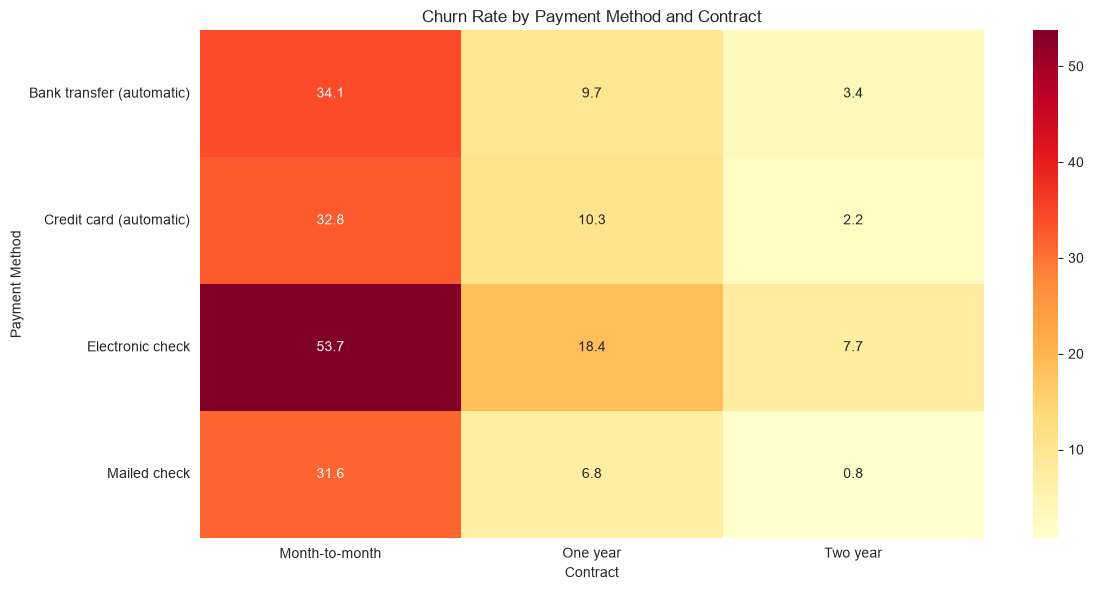

In [71]:
pivot3 = pd.pivot_table(
    df,
    values="ChurnNumeric",
    index="PaymentMethod",
    columns="Contract",
    aggfunc="mean"
) * 100

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot3,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Churn Rate by Payment Method and Contract")
plt.xlabel("Contract")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()

In [72]:
service_features = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport"
]

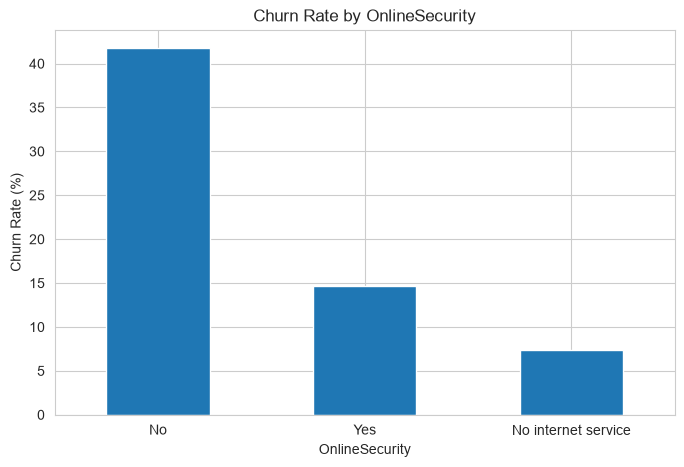

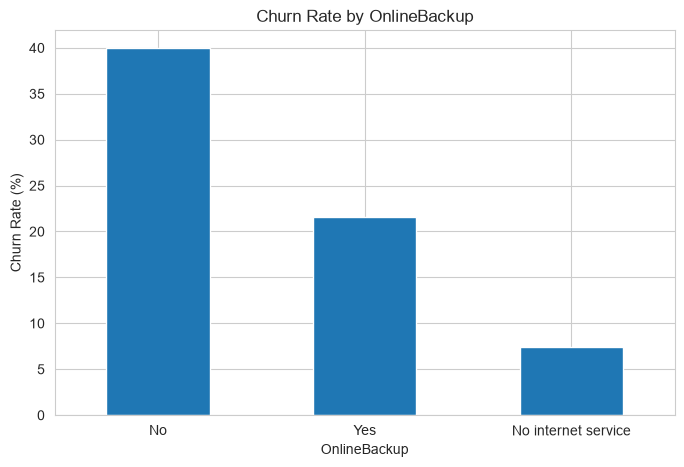

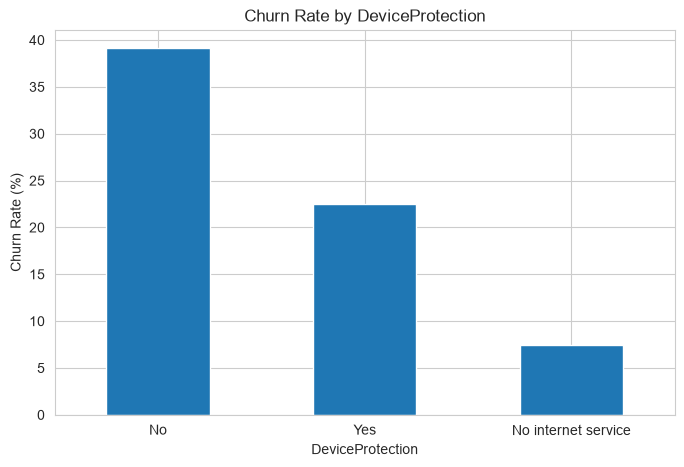

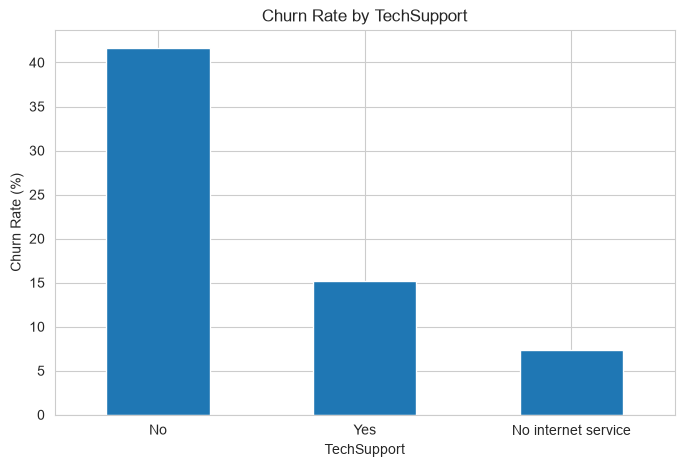

In [73]:
for feature in service_features:

    rate = (
        df.groupby(feature)["ChurnNumeric"]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    plt.figure(figsize=(8, 5))

    rate.plot(kind="bar")

    plt.title(f"Churn Rate by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Churn Rate (%)")

    plt.xticks(rotation=0)

    plt.show()

In [80]:
profile = pd.crosstab(
    [df["SeniorCitizen"], df["Partner"]],
    df["Churn"],
    normalize="index"
) * 100

profile

Churn                         No        Yes
SeniorCitizen Partner                      
0             No       69.986979  30.013021
              Yes      83.351007  16.648993
1             No       51.142355  48.857645
              Yes      65.445026  34.554974

In [81]:
service_columns = [
    "PhoneService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [82]:
df["ServiceCount"] = 0

df["ServiceCount"] += (
    df["PhoneService"] == "Yes"
).astype(int)

for col in service_columns[1:]:
    df["ServiceCount"] += (
        df[col] == "Yes"
    ).astype(int)

In [83]:
service_churn = (
    df.groupby("ServiceCount")["ChurnNumeric"]
    .mean() * 100
)

service_churn

ServiceCount
0    43.750000
1    21.660009
2    43.473896
3    34.678194
4    27.212806
5    22.007255
6    12.571429
7     5.791506
Name: ChurnNumeric, dtype: float64

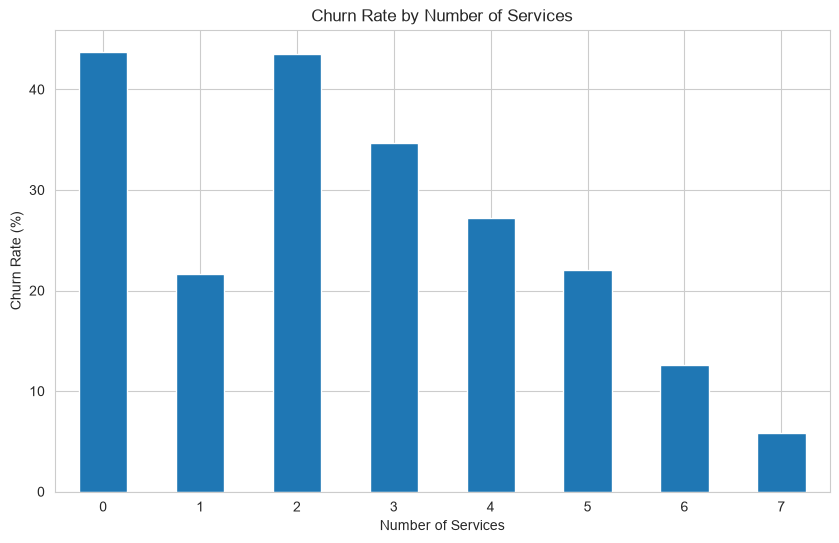

In [84]:
plt.figure(figsize=(10, 6))

service_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [85]:
summary = {}

for column in categorical_features:

    rate = (
        df.groupby(column)["ChurnNumeric"]
        .mean()
        .max()
        * 100
    )

    summary[column] = rate

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Feature", "Highest_Category_Churn_Rate"]
).sort_values(
    "Highest_Category_Churn_Rate",
    ascending=False
)

summary_df

,Feature,Highest_Category_Churn_Rate
14,PaymentMethod,45.285412
12,Contract,42.709677
5,InternetService,41.892765
6,OnlineSecurity,41.766724
9,TechSupport,41.635474
7,OnlineBackup,39.928756
8,DeviceProtection,39.127625
11,StreamingMovies,33.680431
13,PaperlessBilling,33.565092
10,StreamingTV,33.523132
